In [3]:

import os
import shutil
import zipfile
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [4]:
import zipfile

zip_path = "PlantDiseaseData.zip"
extract_path = "/content/PlantData"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [5]:
os.listdir("/content/plantdata")

['New Plant Diseases Dataset(Augmented)', 'test']

In [6]:
os.listdir("/content/plantdata/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train")

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___healthy',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___healthy',
 'Strawberry___Leaf_scorch',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___healthy',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spid

In [7]:
base = "/content/plantdata/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

test_src = "/content/plantdata/test"

clean_dir = "/content/dataset_clean"

In [8]:
os.makedirs(clean_dir, exist_ok=True)

In [9]:
for folder in ["train", "valid"]:
    src = os.path.join(base, folder)
    dst = os.path.join(clean_dir, folder)
    shutil.move(src, dst)

In [11]:


dst = "/content/dataset_clean/test"

if not os.path.exists(dst):
    shutil.move(test_src, dst)
else:
    print("Already moved ✔")

Already moved ✔


In [12]:
os.listdir(clean_dir)

['test', 'train', 'valid']

***Image Data Preprocessing

In [13]:
training_set=tf.keras.utils.image_dataset_from_directory(
    clean_dir + "/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 140590 files belonging to 39 classes.


*** Validation set


In [14]:
validation_set=tf.keras.utils.image_dataset_from_directory(
    clean_dir+"/valid",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    format="tf",
    verbose=True,
)


Found 35144 files belonging to 39 classes.


In [15]:

training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [16]:
for x,y in training_set:
  print(x)
  print(y)
  break;

tf.Tensor(
[[[[166.   172.   146.  ]
   [182.   188.   162.  ]
   [194.5  200.5  174.5 ]
   ...
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]]

  [[150.5  155.5  132.5 ]
   [157.25 162.25 139.25]
   [175.75 180.75 157.75]
   ...
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]]

  [[164.25 167.25 146.25]
   [162.75 165.75 144.75]
   [166.75 169.75 148.75]
   ...
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]
   [  3.     3.     3.  ]]

  ...

  [[  3.     4.     0.  ]
   [  3.     4.     0.  ]
   [  3.     3.     1.  ]
   ...
   [ 53.    72.5   35.25]
   [ 59.75  80.5   41.5 ]
   [ 45.25  66.25  25.75]]

  [[  3.     4.     0.  ]
   [  3.     4.     0.  ]
   [  3.     3.     1.  ]
   ...
   [ 39.5   60.5   21.  ]
   [ 55.    76.25  33.  ]
   [ 59.5   81.25  35.75]]

  [[  3.     4.     0.  ]
   [  3.     4.     0.  ]
   [  3.     3.     1.  ]
   ...
   [ 44.75  67.5   25.75]
   [ 56.25  77.75  33.  ]
   [ 57.75  77.25  2

***BUILDING MODEL

In [17]:
from tensorflow.keras.layers import Dense,Convolution2D,MaxPool2D,Flatten
from tensorflow.keras.models import Sequential


In [18]:
model = Sequential()

 CONVOLYUTIONAL LAYER

In [20]:
model.add(Convolution2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Convolution2D(filters=32,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.add(Convolution2D(filters=64,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Convolution2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(Convolution2D(filters=128,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Convolution2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [23]:
model.add(Convolution2D(filters=256,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Convolution2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(Flatten())

In [25]:
model.add(Dense(units=1024,activation='relu'))

In [26]:
# Output Layer
model.add(Dense (units=38,activation='softmax'))

**COMPILING MODEL

In [27]:
model.compile(optimizer='adam' ,loss='categorical_crossentropy',metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    16,778,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        38,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,989,446 (68.62 MB)

 Trainable params: 17,989,446 (68.62 MB)

 Non-trainable params: 0 (0.00 B)

TRAINING MODEL

In [29]:
training_history=model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 153s 64ms/step - accuracy: 0.6834 - loss: 1.1038 - val_accuracy: 0.8658 - val_loss: 0.4062
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 127s 58ms/step - accuracy: 0.8865 - loss: 0.3468 - val_accuracy: 0.8920 - val_loss: 0.3466
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 127s 58ms/step - accuracy: 0.9201 - loss: 0.2433 - val_accuracy: 0.8867 - val_loss: 0.3834
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9372 - loss: 0.1901 - val_accuracy: 0.9167 - val_loss: 0.2945
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9468 - loss: 0.1636 - val_accuracy: 0.9173 - val_loss: 0.2907
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 0.9541 - loss: 0.1425 - val_accuracy: 0.9185 - val_loss: 0.2845
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 134s 61ms/step - accuracy: 0.9569 - loss: 0.1318 - val_accuracy: 0.9165 - val_loss: 0.3093
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 126s 57ms/step - accuracy: 

MODEL EVALUTION ON TRAINING SET

In [30]:
training_loss,training_accuracy =model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 50s 23ms/step - accuracy: 0.9701 - loss: 0.0947


In [37]:
print(f"The model training loss is {training_loss}")
print(f"The model training accuracy is {training_accuracy}")

The model training loss is 0.09470691531896591
The model training accuracy is 0.9700547456741333


MODEL EVALUTION ON TRAINING SET

In [38]:
validation_loss,validation_accuracy =model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 12s 22ms/step - accuracy: 0.9143 - loss: 0.3502


In [39]:
print(f"The model validation loss is {validation_loss}")
print(f"The model validation accuracy is {validation_accuracy}")

The model validation loss is 0.3502219617366791
The model validation accuracy is 0.914295494556427


SAVING MODEL

In [35]:
model.save('/content/drive/MyDrive/plant_disease_model.keras')

SAVING HISTORY OF EPOCHS

In [36]:
training_history.history

{'accuracy': [0.6834341287612915,
  0.8864641785621643,
  0.9201081395149231,
  0.9371932744979858,
  0.946795642375946,
  0.9540934562683105,
  0.9569243788719177,
  0.9586457014083862,
  0.9617611765861511,
  0.968020498752594],
 'loss': [1.1037638187408447,
  0.3468065559864044,
  0.24333661794662476,
  0.19006824493408203,
  0.16357408463954926,
  0.14247414469718933,
  0.13181175291538239,
  0.12980924546718597,
  0.11824862658977509,
  0.10238349437713623],
 'val_accuracy': [0.8658092617988586,
  0.8919872641563416,
  0.8866947293281555,
  0.9166856408119202,
  0.9172547459602356,
  0.9185067415237427,
  0.9165149331092834,
  0.9240837693214417,
  0.9291486740112305,
  0.914295494556427],
 'val_loss': [0.4061666429042816,
  0.3465973436832428,
  0.38337990641593933,
  0.29448601603507996,
  0.2906833291053772,
  0.28447237610816956,
  0.3092866539955139,
  0.30413421988487244,
  0.28009113669395447,
  0.35022199153900146]}

RECORDING HISTORY IN JSON

In [42]:
import json
with open("training_history.json", "w") as f:
 json.dump(training_history.history , f)

ACCURACY VISULISATION

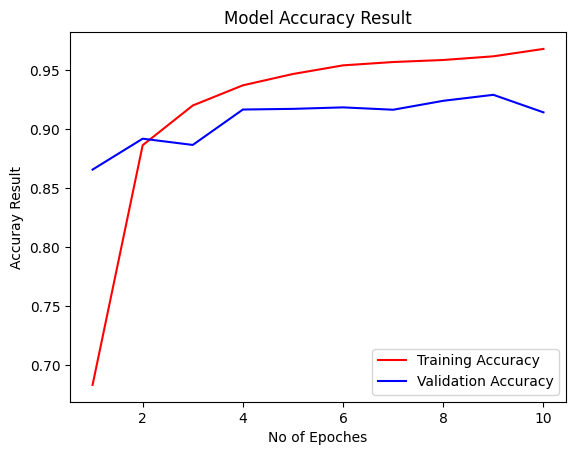

In [50]:
epoches=[i for i in range (1,11)]
plt.plot(epoches,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epoches,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel("No of Epoches")
plt.ylabel("Accuray Result")
plt.title("Model Accuracy Result")
plt.legend()
plt.show()

OTHER MATRICES FOR MODEL EVALUATION

In [64]:
y_pred=model.predict(test)

550/550 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step


In [14]:
validation_set.class_names

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_